In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Load your embeddings
embeddings_df = pd.read_csv('lstm_embeddings.csv', index_col=0, parse_dates=True)
embeddings = embeddings_df.values

print("Embeddings shape:", embeddings.shape)
print("Date range:", embeddings_df.index[0], "to", embeddings_df.index[-1])

Embeddings shape: (7887, 16)
Date range: 1993-09-02 00:00:00 to 2024-12-30 00:00:00


K=2 | Inertia: 5094.7 | Silhouette: 0.2425 | BIC: -218341.8
K=3 | Inertia: 4563.7 | Silhouette: 0.1342 | BIC: -230695.2
K=4 | Inertia: 4171.1 | Silhouette: 0.1384 | BIC: -242111.9
K=5 | Inertia: 3871.1 | Silhouette: 0.1359 | BIC: -248103.6
K=6 | Inertia: 3646.1 | Silhouette: 0.1315 | BIC: -253118.9


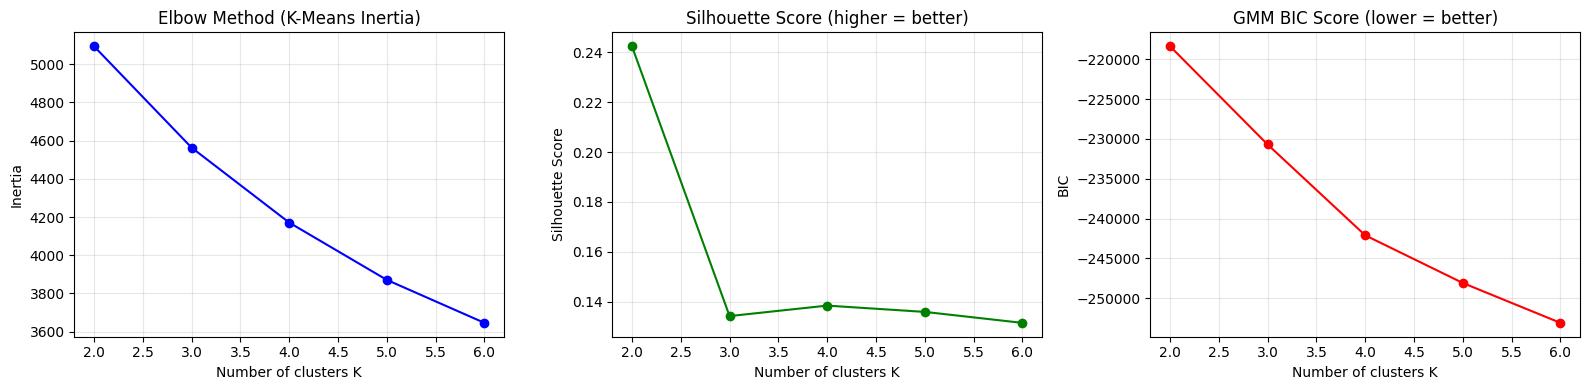

Saved: cluster_selection.png


In [2]:
# Test K = 2, 3, 4, 5
# Two metrics: inertia (elbow) and silhouette score
inertias    = []
silhouettes = []
bic_scores  = []
K_range     = range(2, 7)

for k in K_range:
    # K-Means
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(embeddings, labels))

    # GMM BIC (lower = better)
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(embeddings)
    bic_scores.append(gmm.bic(embeddings))

    print(f"K={k} | Inertia: {km.inertia_:.1f} | "
          f"Silhouette: {silhouette_score(embeddings, labels):.4f} | "
          f"BIC: {gmm.bic(embeddings):.1f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_title('Elbow Method (K-Means Inertia)')
axes[0].set_xlabel('Number of clusters K')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), silhouettes, 'go-')
axes[1].set_title('Silhouette Score (higher = better)')
axes[1].set_xlabel('Number of clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

axes[2].plot(list(K_range), bic_scores, 'ro-')
axes[2].set_title('GMM BIC Score (lower = better)')
axes[2].set_xlabel('Number of clusters K')
axes[2].set_ylabel('BIC')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_selection.png', dpi=150)
plt.show()
print("Saved: cluster_selection.png")

In [4]:
# K=3 gives bull, bear, crisis — most interpretable
K = 3

# K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(embeddings)

# GMM
gmm = GaussianMixture(n_components=K, random_state=42)
gmm.fit(embeddings)
gmm_labels = gmm.predict(embeddings)
gmm_probs  = gmm.predict_proba(embeddings)

print("K-Means label distribution:")
unique, counts = np.unique(kmeans_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Regime {u}: {c} days ({c/len(kmeans_labels)*100:.1f}%)")

print("\nGMM label distribution:")
unique, counts = np.unique(gmm_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Regime {u}: {c} days ({c/len(gmm_labels)*100:.1f}%)")

K-Means label distribution:
  Regime 0: 3305 days (41.9%)
  Regime 1: 2916 days (37.0%)
  Regime 2: 1666 days (21.1%)

GMM label distribution:
  Regime 0: 1373 days (17.4%)
  Regime 1: 5179 days (65.7%)
  Regime 2: 1335 days (16.9%)


In [5]:
# Load your original feature data to get dates
features = pd.read_csv('features_20d.csv', index_col=0, parse_dates=True)

# Create regime dataframe aligned to embedding dates
regime_df = pd.DataFrame({
    'kmeans_regime': kmeans_labels,
    'gmm_regime':    gmm_labels,
    'gmm_prob_0':    gmm_probs[:, 0],
    'gmm_prob_1':    gmm_probs[:, 1],
    'gmm_prob_2':    gmm_probs[:, 2],
}, index=embeddings_df.index)

# Merge with features for analysis
analysis = features.join(regime_df, how='inner')

print("Analysis dataframe shape:", analysis.shape)
print(analysis.head())

# Save
regime_df.to_csv('regime_labels.csv')
analysis.to_csv('analysis_with_regimes.csv')
print("\nSaved: regime_labels.csv")
print("Saved: analysis_with_regimes.csv")

Analysis dataframe shape: (7887, 13)
            rolling_mean  realized_vol  skewness  kurtosis  vix_level  \
Date                                                                    
1993-09-02      0.001448      0.054906  0.507621  0.100496      11.87   
1993-09-03      0.001391      0.055116  0.549134  0.090174      11.16   
1993-09-07      0.000858      0.059847  0.407082  0.183869      12.90   
1993-09-08      0.000795      0.061035  0.366886  0.071209      13.24   
1993-09-09      0.000775      0.060929  0.382483  0.099568      12.67   

            vix_change  vix_spread  corr_sp500_vix  kmeans_regime  gmm_regime  \
Date                                                                            
1993-09-02    0.033972    0.063794       -0.202787              0           1   
1993-09-03   -0.059815    0.056484       -0.130104              0           1   
1993-09-07    0.155914    0.069153       -0.422461              0           1   
1993-09-08    0.026357    0.071365       -0.47

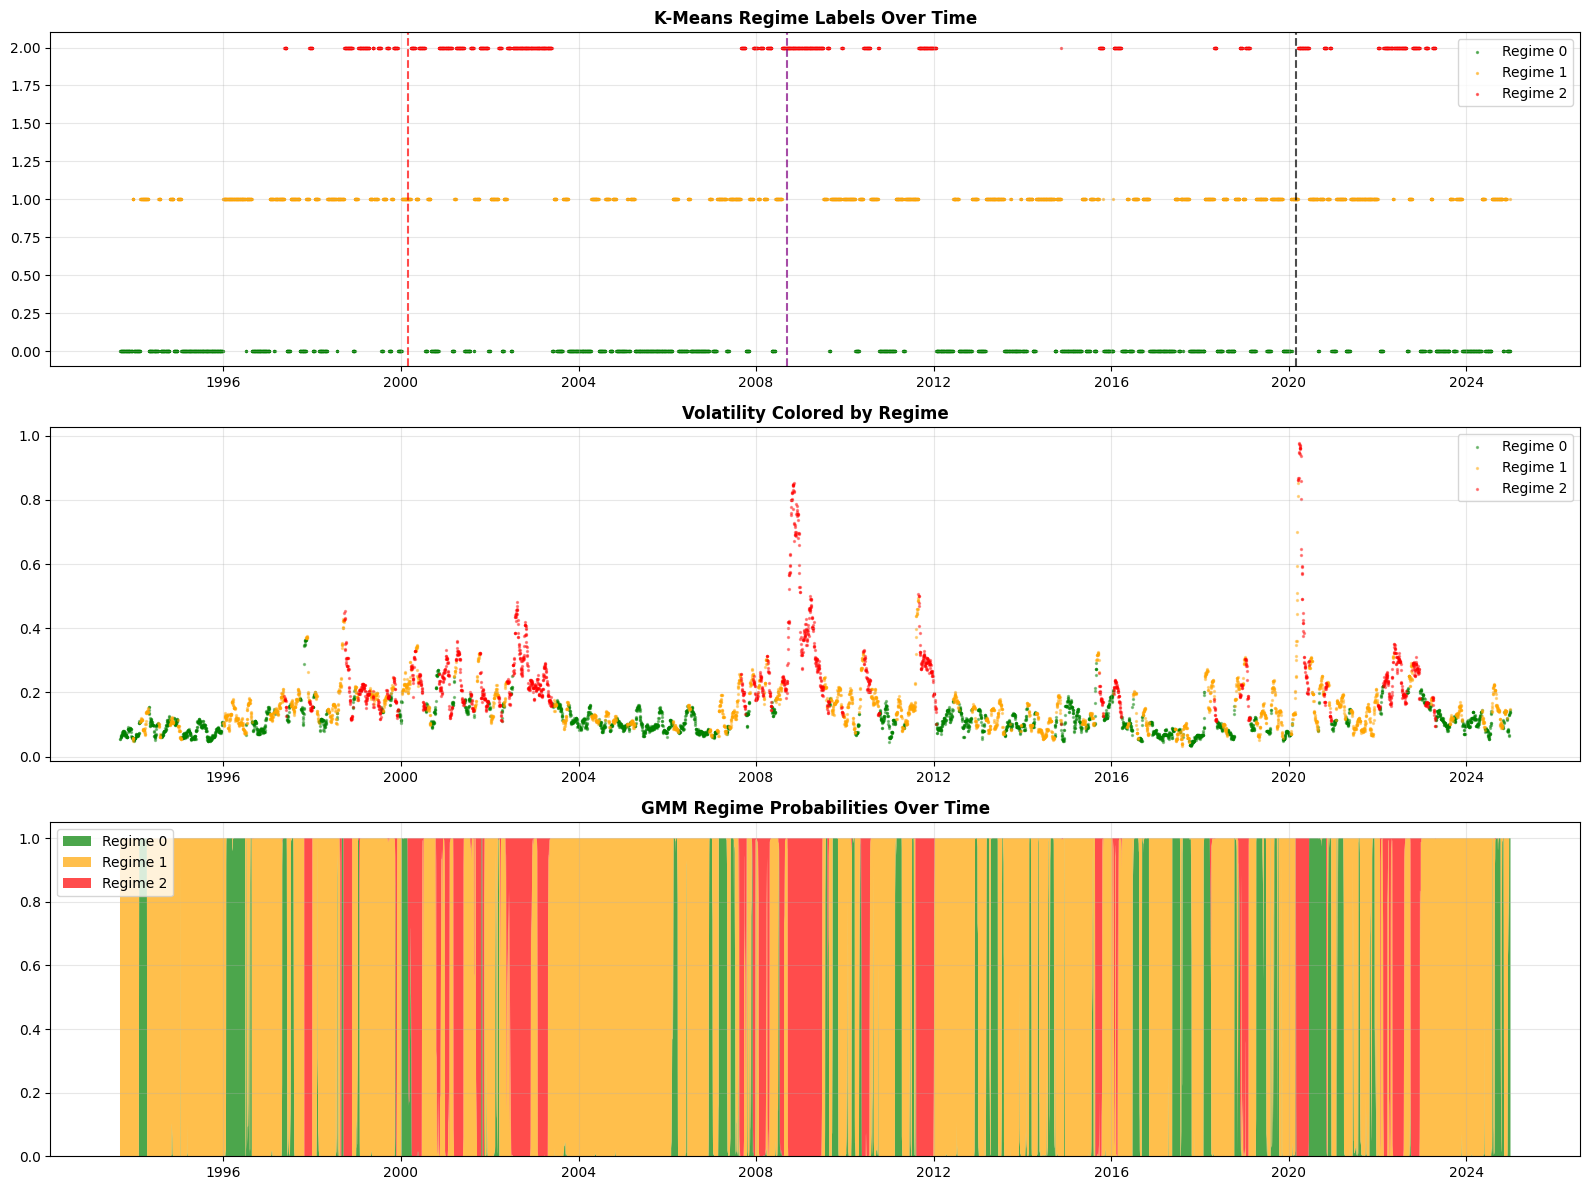

Saved: regimes_over_time.png


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1 — Regime labels over time
ax = axes[0]
colors = {0: 'green', 1: 'orange', 2: 'red'}
for regime in [0, 1, 2]:
    mask = regime_df['kmeans_regime'] == regime
    ax.scatter(regime_df.index[mask],
               regime_df['kmeans_regime'][mask],
               c=colors[regime], s=2, alpha=0.5,
               label=f'Regime {regime}')
ax.set_title('K-Means Regime Labels Over Time', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Crisis markers
for date, label, color in [('2000-03-01','Dot-com','red'),
                             ('2008-09-15','GFC','purple'),
                             ('2020-03-01','COVID','black')]:
    ax.axvline(pd.to_datetime(date), color=color,
               linestyle='--', linewidth=1.5, alpha=0.7)

# Plot 2 — Volatility colored by regime
ax = axes[1]
for regime in [0, 1, 2]:
    mask = analysis['kmeans_regime'] == regime
    ax.scatter(analysis.index[mask],
               analysis['realized_vol'][mask],
               c=colors[regime], s=2, alpha=0.4,
               label=f'Regime {regime}')
ax.set_title('Volatility Colored by Regime', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3 — GMM probabilities
ax = axes[2]
ax.stackplot(regime_df.index,
             regime_df['gmm_prob_0'],
             regime_df['gmm_prob_1'],
             regime_df['gmm_prob_2'],
             colors=['green', 'orange', 'red'],
             alpha=0.7,
             labels=['Regime 0', 'Regime 1', 'Regime 2'])
ax.set_title('GMM Regime Probabilities Over Time', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regimes_over_time.png', dpi=150)
plt.show()
print("Saved: regimes_over_time.png")

In [7]:
##########################UMAP###############################

UMAP output shape: (7887, 2)


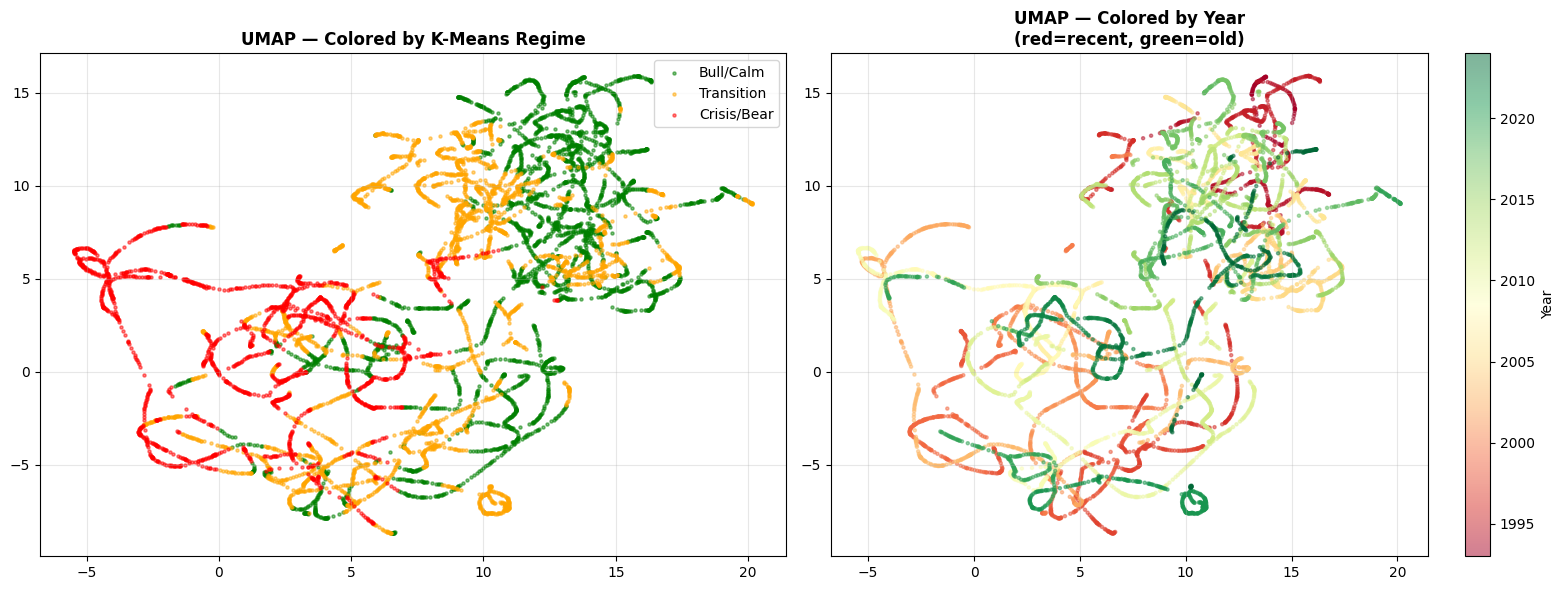

Saved: umap_visualization.png


In [8]:
# Install if needed
import subprocess
subprocess.run(['pip', 'install', 'umap-learn'], capture_output=True)

import umap

# Reduce 16-dim embeddings to 2D
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
emb_2d  = reducer.fit_transform(embeddings)

print("UMAP output shape:", emb_2d.shape)

# Plot colored by K-Means regime
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_map = {0: 'green', 1: 'orange', 2: 'red'}
labels_map  = {0: 'Bull/Calm', 1: 'Transition', 2: 'Crisis/Bear'}

ax = axes[0]
for regime in [0, 1, 2]:
    mask = kmeans_labels == regime
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=colors_map[regime],
               label=labels_map[regime],
               s=5, alpha=0.5)
ax.set_title('UMAP — Colored by K-Means Regime', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot colored by time period to show crisis alignment
ax = axes[1]
dates = embeddings_df.index

# Color by year for temporal view
years = dates.year
scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                     c=years, cmap='RdYlGn',
                     s=5, alpha=0.5)
plt.colorbar(scatter, ax=ax, label='Year')
ax.set_title('UMAP — Colored by Year\n'
             '(red=recent, green=old)', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('umap_visualization.png', dpi=150)
plt.show()
print("Saved: umap_visualization.png")

In [9]:
from scipy.stats import f_oneway, kruskal

# Split each feature by regime
features_to_test = ['realized_vol', 'skewness', 'kurtosis',
                    'vix_spread', 'corr_sp500_vix']

print("=" * 60)
print("STATISTICAL VALIDATION — Are regimes significantly different?")
print("=" * 60)
print(f"\n{'Feature':<20} {'ANOVA p-value':<20} {'Significant?'}")
print("-" * 60)

results = {}
for feat in features_to_test:
    if feat not in analysis.columns:
        continue

    groups = [
        analysis.loc[analysis['kmeans_regime'] == r, feat].dropna().values
        for r in [0, 1, 2]
    ]

    # ANOVA test
    f_stat, p_val = f_oneway(*groups)

    # Kruskal-Wallis (non-parametric backup)
    k_stat, kp_val = kruskal(*groups)

    significant = "YES ✓" if p_val < 0.05 else "NO ✗"
    results[feat] = {'anova_p': p_val, 'kruskal_p': kp_val}

    print(f"{feat:<20} {p_val:<20.6f} {significant}")

print("\n" + "=" * 60)
print("Interpretation:")
print("p < 0.05 = regimes are statistically different for this feature")
print("This PROVES your regimes are real, not random clusters")
print("=" * 60)

STATISTICAL VALIDATION — Are regimes significantly different?

Feature              ANOVA p-value        Significant?
------------------------------------------------------------
realized_vol         0.000000             YES ✓
skewness             0.000000             YES ✓
kurtosis             0.000000             YES ✓
vix_spread           0.000000             YES ✓
corr_sp500_vix       0.000000             YES ✓

Interpretation:
p < 0.05 = regimes are statistically different for this feature
This PROVES your regimes are real, not random clusters



Mean values per regime:
----------------------------------------------------------------------
               realized_vol  skewness  kurtosis  vix_spread  corr_sp500_vix
kmeans_regime                                                              
0                    0.1071    0.0564    0.1231      0.0501         -0.3558
1                    0.1538   -0.3232    0.1855      0.0377         -0.4088
2                    0.2648    0.0861   -0.2520      0.0188         -0.3321


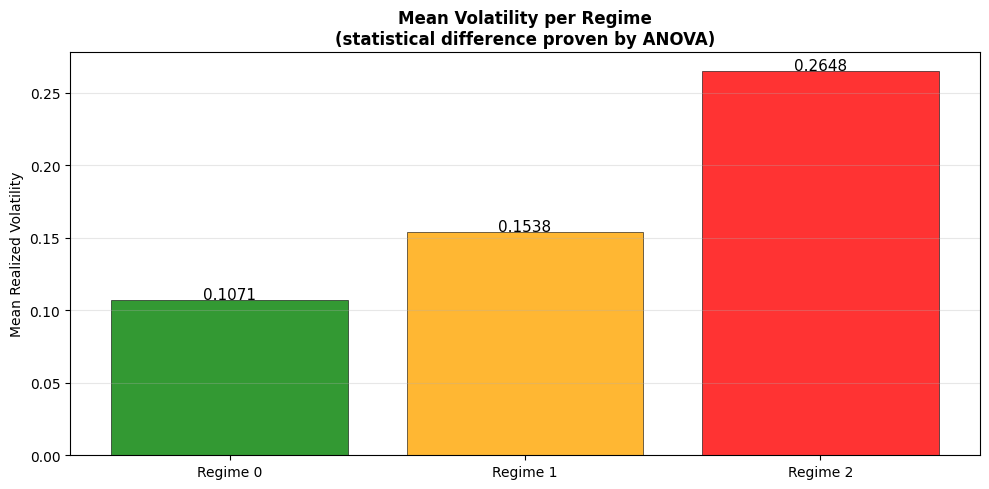

Saved: regime_volatility_comparison.png


In [10]:
print("\nMean values per regime:")
print("-" * 70)

table = analysis.groupby('kmeans_regime')[features_to_test].mean().round(4)
print(table)

# Bar chart of volatility per regime
fig, ax = plt.subplots(figsize=(10, 5))
regime_vol = analysis.groupby('kmeans_regime')['realized_vol'].mean()
bars = ax.bar([f'Regime {i}' for i in regime_vol.index],
              regime_vol.values,
              color=['green', 'orange', 'red'],
              alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set_title('Mean Volatility per Regime\n'
             '(statistical difference proven by ANOVA)',
             fontweight='bold')
ax.set_ylabel('Mean Realized Volatility')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, regime_vol.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('regime_volatility_comparison.png', dpi=150)
plt.show()
print("Saved: regime_volatility_comparison.png")

In [11]:
import os
print("=== All project files ===")
for f in sorted(os.listdir()):
    if f.endswith(('.csv', '.png', '.pt', '.npy', '.ipynb')):
        size = os.path.getsize(f) / 1024
        print(f"  {f:40s} {size:.1f} KB")

=== All project files ===
  06_clustering.ipynb                      436.2 KB
  Analysis.ipynb                           363.8 KB
  LSTM_Autoencoder.ipynb                   11.5 KB
  Untitled.ipynb                           237.6 KB
  analysis_with_regimes.csv                1770.9 KB
  cluster_selection.png                    99.0 KB
  eda_full.png                             586.0 KB
  feature_engineering.ipynb                516.9 KB
  features_20d.csv                         1338.4 KB
  features_60d.csv                         1323.3 KB
  lstm_embeddings.csv                      1466.6 KB
  prices_vs_returns.png                    200.9 KB
  regime_labels.csv                        590.7 KB
  regime_volatility_comparison.png         41.1 KB
  regimes_over_time.png                    384.0 KB
  rolling_volatility.png                   233.6 KB
  sp500_clean.csv                          880.8 KB
  umap_visualization.png                   591.1 KB
  vix_clean.csv                      